# LCR Meter Stability Analysis

Analysis of the design at <https://www.ti.com/lit/ug/tidueu6b/tidueu6b.pdf>

In [1]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import warnings

warnings.simplefilter(action = "ignore", category = RuntimeWarning)

# constants
pi2 = math.pi * 2.0
s = ct.tf('s')
Rf = 100

def plotsys(sys):
    gm, pm, wcg, wcp = ct.margin(sys)
    fcg = wcg / (2 * math.pi)
    fcp = wcp / (2 * math.pi)
    zeros = ct.zeros(sys)
    poles = ct.poles(sys)
    
    print(f"\nTransfer Function: {sys}")
    print(f"\nGain Margin: {gm:.3f}")
    print(f"Phase Margin: {pm:.3f} degrees")
    print(f"Gain Crossover Frequency: {fcp:.3f} Hz")
    print(f"Phase Crossover Frequency: {fcg:.3f} Hz")
    print(f"Zeros: {zeros} rad/s")
    print(f"Poles: {poles} rad/s")

    PM = math.radians(90) + math.atan(wcp * Rs * Cs) - math.atan(wcp * (Rs + Rf) * Cs)
    print('Estimated phase margin', math.degrees(PM))

    # 2. Plot Poles and Zeros
    plt.figure(figsize=(6, 4))
    ct.pole_zero_plot(sys)
    plt.title('Op-Amp Transfer Function Pole-Zero Plot')
    plt.grid(True)
    plt.show()
    
    # 3. Generate the Bode plot
    # This returns magnitude, phase, and frequency arrays
    w = np.logspace(1,9,100)
    out = ct.bode_plot(sys, w, dB=True, Hz=True, deg=True, title="LCR Meter Plot")
    plt.savefig("lcrmeter-plot.pdf", format="pdf")  
    plt.show()



This is the original network

Pole freq wu= 628.3185307179587 f= 100.0

Transfer Function: <TransferFunction>: sys[10]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                  0.01 s
  ---------------------------------------
  1.592e-15 s^3 + 1.602e-10 s^2 + 1e-07 s

Gain Margin: inf
Phase Margin: 2.300 degrees
Gain Crossover Frequency: 398783.572 Hz
Phase Crossover Frequency: nan Hz
Zeros: [0.+0.j] rad/s
Poles: [-100000.        +0.j    -628.31853072+0.j       0.        +0.j] rad/s
Estimated phase margin 2.2854676612616935


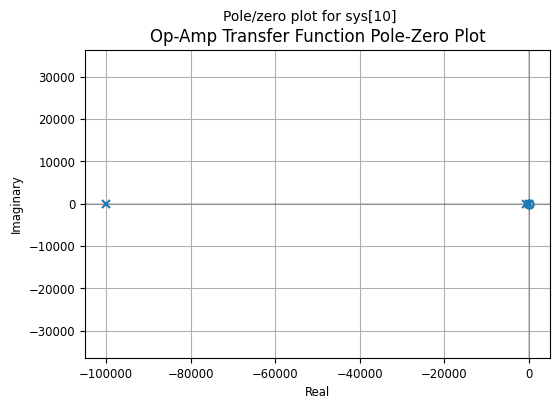

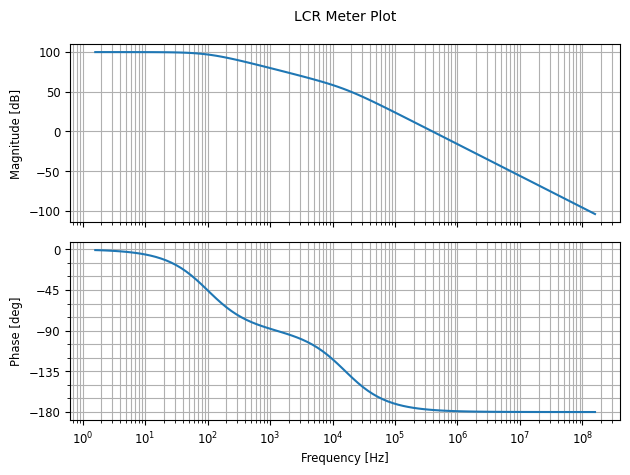

In [2]:
# 1. Define Op-Amp Parameters (e.g., DC gain 10^5, Pole at 100 Hz)
DC_gain = 1e5
f = 100
wu = f * 2 * np.pi  # Convert Hz to rad/s
Aol = ct.tf([DC_gain], [1/wu, 1])
print('Pole freq wu=', wu, 'f=', wu / pi2)

# 2. Define Feedback Network beta = Zs / (Zs + Zf)
Rs = 0
Rf = 100
Cs = 100e-9 # 100nF
s = ct.tf('s')
Zs = Rs + 1.0 / (s * Cs)
Zf = Rf
beta = Zs / (Zf + Zs)



sys = Aol * beta
plotsys(sys)



This is the compensated network

Pole freq wu= 628.3185307179587 f= 100.0

Transfer Function: <TransferFunction>: sys[22]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            1e-07 s^2 + 0.01 s
  ---------------------------------------
  3.183e-15 s^3 + 1.612e-10 s^2 + 1e-07 s

Gain Margin: inf
Phase Margin: 89.910 degrees
Gain Crossover Frequency: 5000018.996 Hz
Phase Crossover Frequency: nan Hz
Zeros: [-100000.+0.j       0.+0.j] rad/s
Poles: [-50000.        +0.j   -628.31853072+0.j      0.        +0.j] rad/s
Estimated phase margin 89.90881182012939


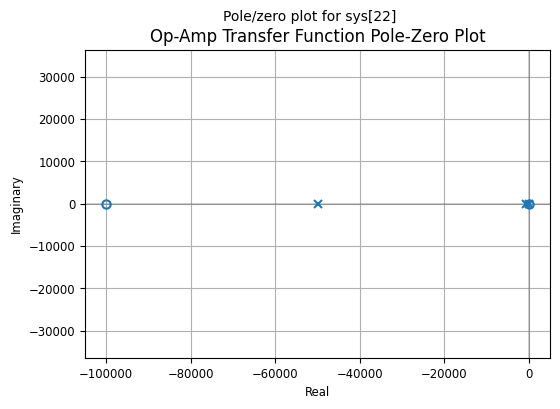

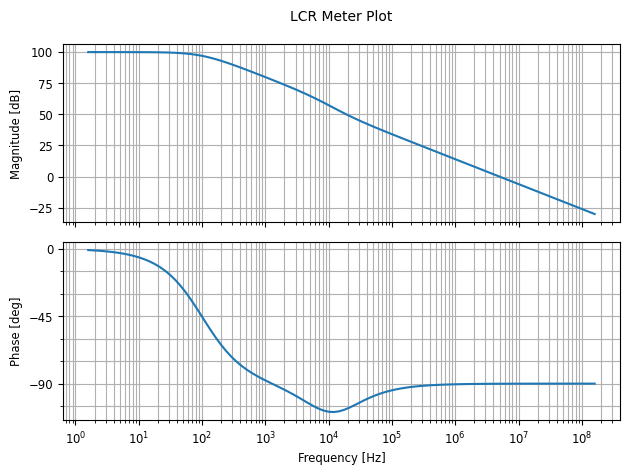

In [3]:
# 1. Define Op-Amp Parameters (e.g., DC gain 10^5, Pole at 100 Hz)
DC_gain = 1e5
f = 100
wu = f * 2 * np.pi  # Convert Hz to rad/s
Aol = ct.tf([DC_gain], [1/wu, 1])
print('Pole freq wu=', wu, 'f=', wu / pi2)

# 2. Define Feedback Network beta = Zs / (Zs + Zf)
Rs = 100
Rf = 100
Cs = 100e-9 # 100nF
s = ct.tf('s')
Zs = Rs + 1.0 / (s * Cs)
Zf = Rf
beta = Zs / (Zf + Zs)

sys = Aol * beta
plotsys(sys)



Adding a capacitor in parallel to Rf of value close to Cs

Pole freq wu= 628.3185307179587 f= 100.0

Transfer Function: <TransferFunction>: sys[90]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            6e-15 s^3 + 6e-10 s^2
  ------------------------------------------
  1.91e-22 s^4 + 2.558e-17 s^3 + 1.6e-14 s^2

Gain Margin: inf
Phase Margin: 90.062 degrees
Gain Crossover Frequency: 4999980.298 Hz
Phase Crossover Frequency: nan Hz
Zeros: [-100000.+0.j       0.+0.j       0.+0.j] rad/s
Poles: [-133333.33333333+0.j    -628.31853072+0.j       0.        +0.j
       0.        +0.j] rad/s
Estimated phase margin 89.9088111143626


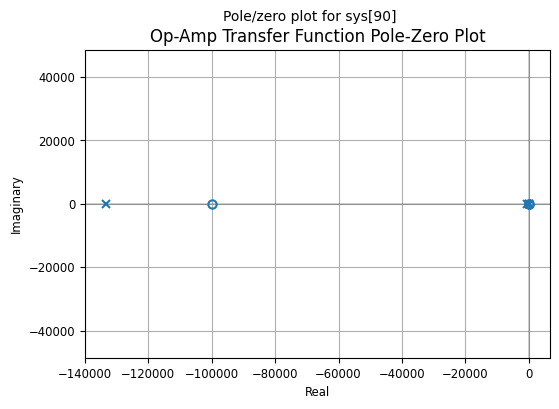

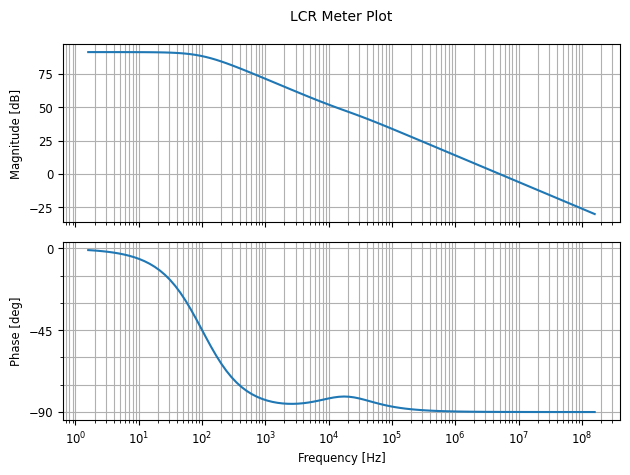

In [7]:
# 1. Define Op-Amp Parameters (e.g., DC gain 10^5, Pole at 100 Hz)
DC_gain = 1e5
f = 100
wu = f * 2 * np.pi  # Convert Hz to rad/s
Aol = ct.tf([DC_gain], [1/wu, 1])
print('Pole freq wu=', wu, 'f=', wu / pi2)

# 2. Define Feedback Network beta = Zs / (Zs + Zf)
Rs = 100
Rf = 100
Cs = 100e-9 # 100nF
Cf = 0.6 * Cs
s = ct.tf('s')
Zs = Rs + 1.0 / (s * Cs)
Zf = Rf + 1.0 / (s * Cf)
beta = Zs / (Zf + Zs)

sys = Aol * beta
plotsys(sys)
